In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import copy

from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

from PIL import Image
import pandas as pd
from pathlib import Path
from tqdm import tqdm

from google.colab import drive

drive.mount("/content/drive")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda
NVIDIA L4


In [2]:
BASE_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data")

TRAIN_CSV = BASE_DIR / "splits/train_split.csv"

GAN_DIR = BASE_DIR / "gan/generated_500kimg_full"

OUT_CSV = BASE_DIR / "splits/train_gan_500kimg_5050.csv"

train_df = pd.read_csv(TRAIN_CSV)

NUM_SYNTHETIC = (train_df["label"] == 0).sum() - (train_df["label"] == 1).sum()
print(NUM_SYNTHETIC)

print(train_df.shape)
print(train_df["label"].value_counts())
print(train_df.columns.tolist())

6318
(8204, 6)
label
0    7261
1     943
Name: count, dtype: int64
['isic_id', 'lesion_id', 'diagnosis_3', 'binary_label', 'label', 'image_path']


In [3]:
def create_augmented_training_csv(
    real_train_df: pd.DataFrame,
    synthetic_dir: Path,
    checkpoint_name: str,
    output_csv: Path,
    num_synthetic: int = NUM_SYNTHETIC,
) -> pd.DataFrame:

    image_paths = sorted(synthetic_dir.glob("*.png"))

    if len(image_paths) < num_synthetic:
        raise ValueError(
            f"Only {len(image_paths)} images found in {synthetic_dir}, "
            f"but {num_synthetic} are required."
        )

    image_paths = image_paths[:num_synthetic]

    synthetic_rows = pd.DataFrame({
        "isic_id": [
            f"synthetic_{checkpoint_name}_{i:05d}"
            for i in range(num_synthetic)
        ],
        "lesion_id": [
            f"synthetic_{checkpoint_name}_{i:05d}"
            for i in range(num_synthetic)
        ],
        "diagnosis_3": ["Melanoma, NOS"] * num_synthetic,
        "binary_label": ["Melanoma"] * num_synthetic,
        "label": [1] * num_synthetic,
        "image_path": [str(path) for path in image_paths],
    })

    synthetic_rows = synthetic_rows[real_train_df.columns]

    augmented_df = pd.concat(
        [real_train_df, synthetic_rows],
        ignore_index=True
    )

    augmented_df.to_csv(output_csv, index=False)

    print(f"Saved: {output_csv}")
    print(f"Total rows: {len(augmented_df)}")
    print(augmented_df["label"].value_counts())

    return augmented_df

In [ ]:
train_df = create_augmented_training_csv(
    real_train_df=train_df,
    synthetic_dir=GAN_DIR,
    checkpoint_name="gan500",
    output_csv=OUT_CSV,
    num_synthetic=NUM_SYNTHETIC,
)

In [3]:
SPLIT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/splits")

train_df = pd.read_csv(SPLIT_DIR / "train_gan_500kimg_5050.csv")
val_df = pd.read_csv(SPLIT_DIR / "val_split.csv")
test_df = pd.read_csv(SPLIT_DIR / "test_split.csv")

print(train_df.head())
print(train_df["label"].value_counts())

        isic_id   lesion_id                 diagnosis_3  binary_label  label  \
0  ISIC_0024307  IL_6125741                       Nevus  Non-Melanoma      0   
1  ISIC_0024308  IL_3692653                       Nevus  Non-Melanoma      0   
2  ISIC_0024309  IL_0959663                       Nevus  Non-Melanoma      0   
3  ISIC_0024310  IL_8194852               Melanoma, NOS      Melanoma      1   
4  ISIC_0024312  IL_3471258  Pigmented benign keratosis  Non-Melanoma      0   

                                          image_path  
0  /content/drive/MyDrive/bachelor_thesis_data/HA...  
1  /content/drive/MyDrive/bachelor_thesis_data/HA...  
2  /content/drive/MyDrive/bachelor_thesis_data/HA...  
3  /content/drive/MyDrive/bachelor_thesis_data/HA...  
4  /content/drive/MyDrive/bachelor_thesis_data/HA...  
label
0    7261
1    7261
Name: count, dtype: int64


In [4]:
weights = EfficientNet_B0_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
import os
import numpy as np
import random

SEED = 42

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


In [6]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


In [3]:
!mkdir -p /content/HAM10000_images
!rsync -ah --info=progress2 /content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images/ /content/HAM10000_images/

        326.28M 100%   37.86kB/s    2:20:16 (xfr#11721, to-chk=0/11722)   


In [4]:
!find /content/HAM10000_images -type f | wc -l
!du -sh /content/HAM10000_images

11721
335M	/content/HAM10000_images


In [14]:
from pathlib import Path

old_real_path = "/content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images"
new_real_path = "/content/HAM10000_images"

val_df["image_path"] = val_df["image_path"].str.replace(
    old_real_path,
    new_real_path,
    regex=False
)

test_df["image_path"] = test_df["image_path"].str.replace(
    old_real_path,
    new_real_path,
    regex=False
)

In [7]:
import shutil
from pathlib import Path

LOCAL_GAN_DIR = Path("/content/gan_images")

LOCAL_GAN_DIR.mkdir(parents=True, exist_ok=True)

def copy_synthetic_images(
    train_df: pd.DataFrame,
    local_directory: Path
):
    synthetic_df = train_df[
        train_df["isic_id"].astype(str).str.startswith("synthetic_")
    ]

    print(f"Synthetic rows found: {len(synthetic_df)}")

    for source_path in tqdm(
        synthetic_df["image_path"],
        desc=f"Copying to {local_directory.name}"
    ):
        source_path = Path(source_path)
        destination_path = local_directory / source_path.name

        if not destination_path.exists():
            shutil.copy2(source_path, destination_path)

    copied_count = len(list(local_directory.glob("*.png")))
    print(f"Images available locally: {copied_count}")

copy_synthetic_images(
    train_df,
    LOCAL_GAN_DIR
)


Synthetic rows found: 6318


Copying to gan_images:   0%|          | 4/6318 [00:04<1:54:59,  1.09s/it]


KeyboardInterrupt: 

In [16]:
def convert_to_local_paths(
    dataframe: pd.DataFrame,
    local_synthetic_directory: Path
):
    dataframe = dataframe.copy()

    synthetic_mask = (
        dataframe["isic_id"]
        .astype(str)
        .str.startswith("synthetic_")
    )

    # Synthetic images
    dataframe.loc[synthetic_mask, "image_path"] = (
        dataframe.loc[synthetic_mask, "image_path"]
        .apply(
            lambda path:
            str(local_synthetic_directory / Path(path).name)
        )
    )

    dataframe.loc[~synthetic_mask, "image_path"] = (
        dataframe.loc[~synthetic_mask, "image_path"]
        .apply(
            lambda path:
            str(Path("/content/HAM10000_images") / Path(path).name)
        )
    )

    return dataframe

train_df = convert_to_local_paths(
    train_df,
    LOCAL_GAN_DIR
)

In [17]:
def check_paths(name, dataframe):
    exists = dataframe["image_path"].apply(
        lambda path: Path(path).exists()
    )

    print(f"{name}:")
    print(f"  Total rows: {len(dataframe)}")
    print(f"  Existing files: {exists.sum()}")
    print(f"  Missing files: {(~exists).sum()}")

    if (~exists).any():
        print("\nExample missing paths:")
        print(
            dataframe.loc[~exists, "image_path"].head()
        )

check_paths("Training set", train_df)
check_paths("Validation set", val_df)
check_paths("Test set", test_df)

Training set:
  Total rows: 14522
  Existing files: 14522
  Missing files: 0
Validation set:
  Total rows: 1742
  Existing files: 1742
  Missing files: 0
Test set:
  Total rows: 1774
  Existing files: 1774
  Missing files: 0


In [8]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]
        label = row["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [9]:
BATCH_SIZE = 32

generator = torch.Generator()
generator.manual_seed(SEED)

train_dataset = MelanomaDataset(train_df, transform=train_transform)
val_dataset = MelanomaDataset(val_df, transform=val_test_transform)
test_dataset = MelanomaDataset(test_df, transform=val_test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker
)

In [10]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)

            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    epoch_loss = running_loss / len(dataloader.dataset)

    return epoch_loss, all_labels, all_probs

In [22]:
print("Training rows:", len(train_df))
print(train_df["label"].value_counts().sort_index())

assert len(train_df) == 14522
assert (train_df["label"] == 0).sum() == 7261
assert (train_df["label"] == 1).sum() == 7261
assert train_df["image_path"].apply(
    lambda path: Path(path).exists()
).all()

print("Final checks passed. Ready to train.")

Training rows: 14522
label
0    7261
1    7261
Name: count, dtype: int64
Final checks passed. Ready to train.


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

#recreate model from scratch

set_seed(SEED)
generator.manual_seed(SEED)

weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def calculate_metrics(labels, probs, threshold=0.5):
    preds = [1 if p >= threshold else 0 for p in probs]

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

EPOCHS = 50

history = []
best_val_f1 = -1.0
best_model_state = None
best_epoch = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_labels, val_probs = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    val_metrics = calculate_metrics(
        labels=val_labels,
        probs=val_probs,
        threshold=0.5
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "roc_auc": val_metrics["roc_auc"]
    }

    history.append(epoch_results)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_loss:.4f}")
    print(f"Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f}")
    print(f"Recall: {val_metrics['recall']:.4f}")
    print(f"F1-score: {val_metrics['f1']:.4f}")
    print(f"ROC-AUC: {val_metrics['roc_auc']:.4f}")

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print("New best model saved.")

history_df = pd.DataFrame(history)

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation F1-score: {best_val_f1:.4f}")

CHECKPOINT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/checkpoints")
RESULTS_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/tables")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    best_model_state,
    CHECKPOINT_DIR / "gan_augmentation_500kimg_5050_50epoch.pth"
)

history_df.to_csv(
    RESULTS_DIR / "gan_augmentation_500kimg_5050_training_history50epoch.csv",
    index=False
)

print("\nSaved:")
print(CHECKPOINT_DIR / "gan_augmentation_500kimg_5050_50epoch.pth")
print(RESULTS_DIR / "gan_augmentation_500kimg_5050_training_history50epoch.csv")

best_val_loss, best_val_labels, best_val_probs = evaluate(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

best_val_metrics = calculate_metrics(
    labels=best_val_labels,
    probs=best_val_probs,
    threshold=0.5
)

best_val_preds = [1 if p >= 0.5 else 0 for p in best_val_probs]
best_cm = confusion_matrix(best_val_labels, best_val_preds)

print("\nBest model validation results:")
print(f"Val loss: {best_val_loss:.4f}")
print(f"Accuracy: {best_val_metrics['accuracy']:.4f}")
print(f"Precision: {best_val_metrics['precision']:.4f}")
print(f"Recall: {best_val_metrics['recall']:.4f}")
print(f"F1-score: {best_val_metrics['f1']:.4f}")
print(f"ROC-AUC: {best_val_metrics['roc_auc']:.4f}")
print("Confusion matrix:")
print(best_cm)

history_df


Epoch 1/50


100%|██████████| 55/55 [00:04<00:00, 12.63it/s]


Train loss: 0.2088
Val loss: 0.2367
Accuracy: 0.8938
Precision: 0.5303
Recall: 0.3627
F1-score: 0.4308
ROC-AUC: 0.8959
New best model saved.

Epoch 2/50


100%|██████████| 55/55 [00:04<00:00, 12.90it/s]


Train loss: 0.1087
Val loss: 0.2255
Accuracy: 0.9053
Precision: 0.6014
Recall: 0.4301
F1-score: 0.5015
ROC-AUC: 0.9106
New best model saved.

Epoch 3/50


...

100%|██████████| 55/55 [00:04<00:00, 12.69it/s]


Train loss: 0.0030
Val loss: 0.6237
Accuracy: 0.9150
Precision: 0.6923
Recall: 0.4197
F1-score: 0.5226
ROC-AUC: 0.8802

Training finished.
Best epoch: 19
Best validation F1-score: 0.5904

Saved:
/content/drive/MyDrive/bachelor_thesis_data/checkpoints/gan_augmentation_500kimg_5050_50epoch.pth
/content/drive/MyDrive/bachelor_thesis_data/results/tables/gan_augmentation_500kimg_5050_training_history50epoch.csv


100%|██████████| 55/55 [00:04<00:00, 12.87it/s]


Best model validation results:
Val loss: 0.4421
Accuracy: 0.9116
Precision: 0.6066
Recall: 0.5751
F1-score: 0.5904
ROC-AUC: 0.9054
Confusion matrix:
[[1477   72]
 [  82  111]]


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.208842,0.236731,0.893800,0.530303,0.362694,0.430769,0.895868
1,2,0.108737,0.225493,0.905281,0.601449,0.430052,0.501511,0.910613
2,3,0.069805,0.253124,0.902411,0.573248,0.466321,0.514286,0.906425
3,4,0.045539,0.297920,0.902985,0.565934,0.533679,0.549333,0.897952
4,5,0.028660,0.351056,0.907003,0.608392,0.450777,0.517857,0.883833
5,6,0.023259,0.377257,0.902985,0.589552,0.409326,0.483180,0.880347
6,7,0.017936,0.381865,0.908726,0.666667,0.352332,0.461017,0.884348
7,8,0.016401,0.353174,0.908726,0.606250,0.502591,0.549575,0.900561
8,9,0.013313,0.387953,0.907003,0.628099,0.393782,0.484076,0.883829
9,10,0.015038,0.425087,0.909300,0.649573,0.393782,0.490323,0.899360


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from torchvision import models

model = models.efficientnet_b0(weights=None)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/checkpoints/"
    "gan_augmentation_500kimg_5050_50epoch.pth"
)

best_model_state = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=True
)

model.load_state_dict(best_model_state)
model = model.to(device)
model.eval()

print(f"Loaded best checkpoint: {CHECKPOINT_PATH}")

criterion = nn.BCEWithLogitsLoss()

test_loss, test_labels, test_probs = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

test_preds = [
    1 if probability >= 0.5 else 0
    for probability in test_probs
]

test_accuracy = accuracy_score(
    test_labels,
    test_preds
)

test_precision = precision_score(
    test_labels,
    test_preds,
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_preds,
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_preds,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    test_labels,
    test_probs
)

test_cm = confusion_matrix(
    test_labels,
    test_preds
)

print("E4 GAN-500 50/50 melanoma test results:")
print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print("Confusion matrix:")
print(test_cm)

'''gan_test_results = pd.DataFrame([{
    "experiment": "E4_GAN500_5050_melanoma",
    "gan_checkpoint_kimg": 500,
    "synthetic_melanoma_images": 6318,
    "model": "EfficientNet-B0",
    "seed": SEED,
    "best_epoch": best_epoch,
    "threshold": 0.5,
    "test_loss": test_loss,
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "roc_auc": test_roc_auc,
    "true_negatives": int(test_cm[0, 0]),
    "false_positives": int(test_cm[0, 1]),
    "false_negatives": int(test_cm[1, 0]),
    "true_positives": int(test_cm[1, 1])
}])'''

RESULTS_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/tables"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

'''OUTPUT_PATH = (
    RESULTS_DIR /
    "gan_augmentation_5050_500kimg_test_results.csv"
)

gan_test_results.to_csv(
    OUTPUT_PATH,
    index=False
)'''

# print("\nSaved:")
# print(OUTPUT_PATH)
# gan_test_results

test_labels_array = np.asarray(test_labels).reshape(-1).astype(int)
test_probs_array = np.asarray(test_probs).reshape(-1).astype(float)
test_preds_array = (test_probs_array >= 0.5).astype(int)

gan_balanced_test_predictions = pd.DataFrame({
    "y_true": test_labels_array,
    "y_probability": test_probs_array,
    "y_pred_0_5": test_preds_array
})

prediction_path = (
    RESULTS_DIR /
    "gan_augmentation_5050_500kimg_test_predictions.csv"
)

gan_balanced_test_predictions.to_csv(
    prediction_path,
    index=False
)

print(f"Saved predictions to: {prediction_path}")
print(
    f"Number of predictions: "
    f"{len(gan_balanced_test_predictions)}"
)
print(
    f"Melanoma images: "
    f"{gan_balanced_test_predictions['y_true'].sum()}"
)
print(
    "Non-melanoma images:",
    (gan_balanced_test_predictions["y_true"] == 0).sum()
)

gan_balanced_test_predictions.head()

Loaded best checkpoint: /content/drive/MyDrive/bachelor_thesis_data/checkpoints/gan_augmentation_500kimg_5050_50epoch.pth


100%|██████████| 56/56 [10:23<00:00, 11.13s/it] 


E4 GAN-500 50/50 melanoma test results:
Test loss: 0.3959
Accuracy: 0.9154
Precision: 0.5590
Recall: 0.5325
F1-score: 0.5455
ROC-AUC: 0.8929
Confusion matrix:
[[1534   71]
 [  79   90]]
Saved predictions to: /content/drive/MyDrive/bachelor_thesis_data/results/tables/gan_augmentation_5050_500kimg_test_predictions.csv
Number of predictions: 1774
Melanoma images: 169
Non-melanoma images: 1605


,y_true,y_probability,y_pred_0_5
0,0,7.524466e-06,0
1,0,2.924390e-04,0
2,0,9.269822e-16,0
3,0,3.607221e-12,0
4,0,5.878793e-10,0


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.208842,0.236731,0.893800,0.530303,0.362694,0.430769,0.895868
1,2,0.108737,0.225493,0.905281,0.601449,0.430052,0.501511,0.910613
2,3,0.069805,0.253124,0.902411,0.573248,0.466321,0.514286,0.906425
3,4,0.045539,0.297920,0.902985,0.565934,0.533679,0.549333,0.897952
4,5,0.028660,0.351056,0.907003,0.608392,0.450777,0.517857,0.883833
5,6,0.023259,0.377257,0.902985,0.589552,0.409326,0.483180,0.880347
6,7,0.017936,0.381865,0.908726,0.666667,0.352332,0.461017,0.884348
7,8,0.016401,0.353174,0.908726,0.606250,0.502591,0.549575,0.900561
8,9,0.013313,0.387953,0.907003,0.628099,0.393782,0.484076,0.883829
9,10,0.015038,0.425087,0.909300,0.649573,0.393782,0.490323,0.899360


Lowest validation loss:
Epoch 2, val_loss = 0.2255

Highest validation F1-score:
Epoch 19, F1 = 0.5904


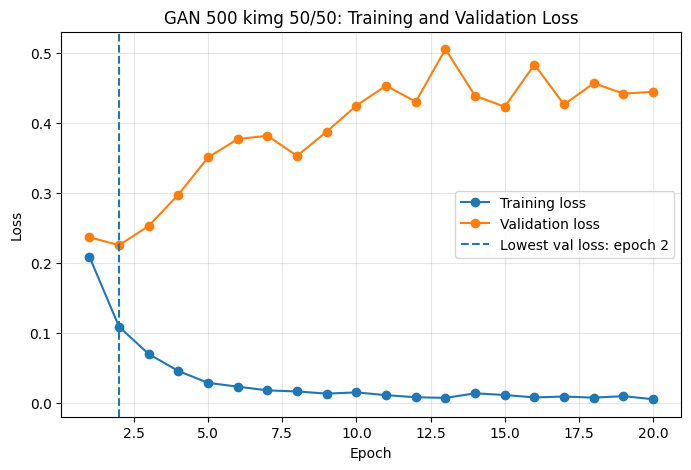

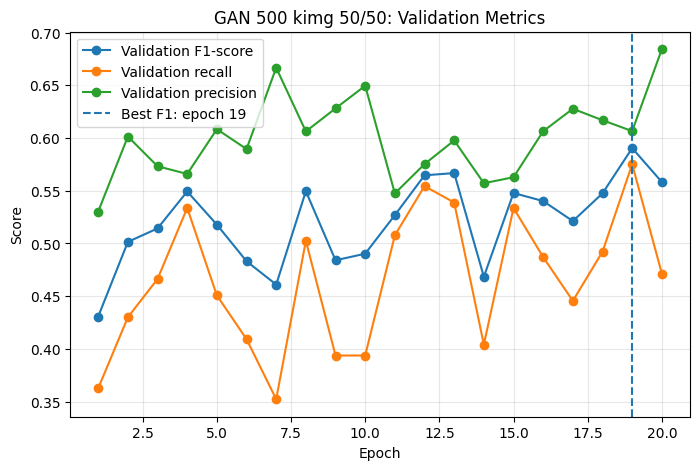

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HISTORY_PATH = "/content/drive/MyDrive/bachelor_thesis_data/results/tables/gan_augmentation_500kimg_5050_training_history.csv"

history_df = pd.read_csv(HISTORY_PATH)

display(history_df)

best_val_loss_idx = history_df["val_loss"].idxmin()
best_val_loss_epoch = int(history_df.loc[best_val_loss_idx, "epoch"])
best_val_loss = history_df.loc[best_val_loss_idx, "val_loss"]

best_f1_idx = history_df["f1"].idxmax()
best_f1_epoch = int(history_df.loc[best_f1_idx, "epoch"])
best_f1 = history_df.loc[best_f1_idx, "f1"]

print("Lowest validation loss:")
print(f"Epoch {best_val_loss_epoch}, val_loss = {best_val_loss:.4f}")

print("\nHighest validation F1-score:")
print(f"Epoch {best_f1_epoch}, F1 = {best_f1:.4f}")

FIGURE_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")

plt.axvline(
    best_val_loss_epoch,
    linestyle="--",
    label=f"Lowest val loss: epoch {best_val_loss_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN 500 kimg 50/50: Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    FIGURE_DIR / "gan_500kimg_5050_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["f1"], marker="o", label="Validation F1-score")
plt.plot(history_df["epoch"], history_df["recall"], marker="o", label="Validation recall")
plt.plot(history_df["epoch"], history_df["precision"], marker="o", label="Validation precision")

plt.axvline(
    best_f1_epoch,
    linestyle="--",
    label=f"Best F1: epoch {best_f1_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("GAN 500 kimg 50/50: Validation Metrics")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    FIGURE_DIR / "gan_500kimg_5050_validation_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

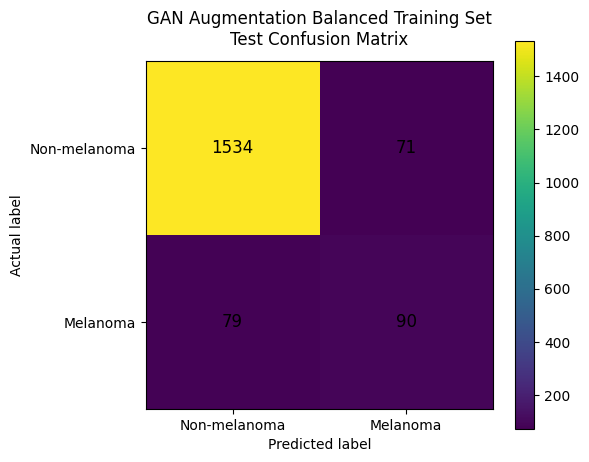

Saved:
/content/drive/MyDrive/bachelor_thesis_data/results/figures/gan_augmentation_5050_500kimg_test_confusion_matrix.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

cm = np.array([
    [1534, 71],
    [79, 90]
])

class_names = ["Non-melanoma", "Melanoma"]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title(
    "GAN Augmentation Balanced Training Set\n"
    "Test Confusion Matrix",
    fontsize=12,
    pad=12
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            int(cm[i, j]),
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

FIGURE_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = (
    FIGURE_DIR /
    "gan_augmentation_5050_500kimg_test_confusion_matrix.png"
)

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_PATH)